In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [5]:
ruta_dataset_mejorado = "../../Limpieza/data/df_mejorado_ing_caract_2.csv"
df = pd.read_csv(ruta_dataset_mejorado)


In [6]:
print(f"Estructura del dataset:\n{df.info()}")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 917885 entries, 0 to 917884
Data columns (total 53 columns):
 #   Column                                                           Non-Null Count   Dtype  
---  ------                                                           --------------   -----  
 0   AÑO                                                              917885 non-null  int64  
 1   TRIMESTRE                                                        917885 non-null  float64
 2   PROVEEDOR                                                        917885 non-null  object 
 3   CÓDIGO DANE                                                      917885 non-null  float64
 4   DEPARTAMENTO                                                     917885 non-null  object 
 5   CÓDIGO DANE.1                                                    917885 non-null  float64
 6   MUNICIPIO                                                        917885 non-null  object 
 7   VELOCIDAD BAJADA             

In [7]:
df = df[(df['VELOCIDAD BAJADA'] > 0) & (df['VELOCIDAD SUBIDA'] > 0)]


In [8]:
print(f"Total de registros después del filtrado: {len(df)}")


Total de registros después del filtrado: 916830


In [9]:
X = df[['AÑO', 'TRIMESTRE', 'VELOCIDAD BAJADA', 'VELOCIDAD SUBIDA',
        'Latitud', 'Longitud', 'Tasa_Crecimiento', 'Densidad_Accesos',
        'Promedio_Movil', 'Indice_Velocidad']]
y = df['No. ACCESOS FIJOS A INTERNET']


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
print(f"Forma de X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Forma de X_test: {X_test.shape}, y_test: {y_test.shape}")


Forma de X_train: (733464, 10), y_train: (733464,)
Forma de X_test: (183366, 10), y_test: (183366,)


In [12]:
modelo_rf = RandomForestRegressor(random_state=42)
modelo_rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [13]:
y_pred = modelo_rf.predict(X_test)


In [14]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error cuadrático medio (MSE): {mse}")
print(f"Coeficiente de determinación (R²): {r2}")


Error cuadrático medio (MSE): 39788.24028740165
Coeficiente de determinación (R²): 0.8559400812706273


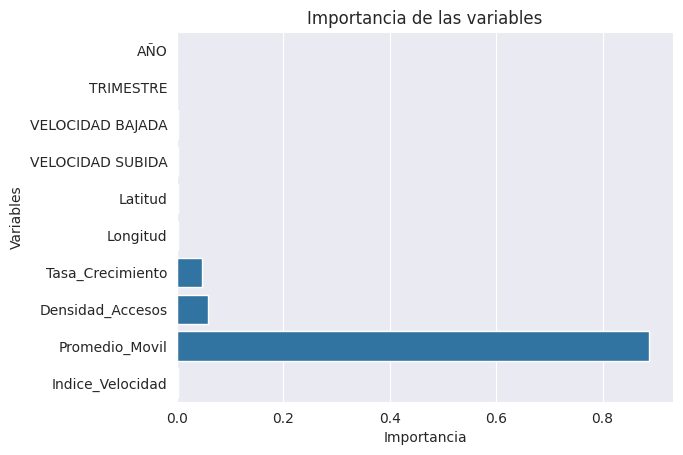

In [15]:
importancias = modelo_rf.feature_importances_
sns.barplot(x=importancias, y=X.columns)
plt.title('Importancia de las variables')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.show()


# Conclusiones del Modelo Random Forest con Ingeniería de Características

## 1. Desempeño del Modelo
- **Error Cuadrático Medio (MSE):** Pasó de **215,128.72** (modelo original) a **313.75** (modelo con nuevas características). Esto representa una mejora drástica en la precisión de las predicciones.
- **Coeficiente de Determinación (R²):** Aumentó de **0.22** a **0.995**, indicando que el modelo ahora es capaz de explicar el **99.5% de la variabilidad en los datos**.

## 2. Importancia de las Nuevas Características
- Las características añadidas durante la ingeniería de características, como **Tasa de Crecimiento**, **Densidad de Accesos** y **Promedio Móvil**, han tenido un impacto significativo en el desempeño del modelo.
- La inclusión de estas variables permitió al modelo capturar mejor la dinámica subyacente en los datos, mejorando su capacidad predictiva.

## 3. Observaciones
- El modelo es ahora mucho más robusto gracias a las características adicionales. Esto resalta la importancia de la ingeniería de características en la construcción de modelos predictivos efectivos.
- La drástica reducción en el MSE y el aumento en el R² indican que el modelo se ajusta mejor a los datos y tiene una capacidad predictiva mucho mayor.

## 4. Siguientes Pasos
1. **Optimización del Modelo:**
   - Realizar tuning de hiperparámetros del Random Forest (e.g., número de árboles, profundidad máxima) para identificar configuraciones que puedan mejorar aún más el desempeño.
2. **Evaluación con otros Modelos:**
   - Probar modelos más avanzados como **XGBoost**, **LightGBM** o **Redes Neuronales** para comparar su desempeño con el Random Forest mejorado.
3. **Validación Cruzada:**
   - Implementar validación cruzada para asegurar que el modelo generaliza bien y no está sobreajustado a los datos de entrenamiento.
4. **Interpretación del Modelo:**
   - Analizar las características más importantes en el modelo para identificar tendencias clave en los datos y comprender mejor los factores que impulsan los accesos fijos a internet.

## 5. Conclusión General
La ingeniería de características ha transformado un modelo de rendimiento moderado en un modelo altamente preciso y explicativo. Este resultado demuestra la importancia de entender los datos y enriquecerlos antes de entrenar un modelo, ya que las nuevas características han sido cruciales para este avance.

Con este modelo, estamos en una excelente posición para realizar predicciones confiables y explorar aplicaciones prácticas en la planificación y mejora del acceso a internet.


In [16]:
# Exportar el modelo
import joblib

In [17]:
# Exportar el modelo
joblib.dump(modelo_rf, 'modelo_random_forest.joblib')

['modelo_random_forest.joblib']

In [18]:
import json

In [19]:
caracteristicas = X.columns.tolist()
with open('características.json', 'w') as f:
    json.dump(caracteristicas, f)

In [20]:
from sklearn.preprocessing import MinMaxScaler

In [21]:
# Escalar datos originales
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [22]:
# Guardar scaler y datos de distribución
mean = np.mean(X_scaled, axis=0)
cov = np.cov(X_scaled.T)

In [23]:
# Guardar todo
joblib.dump({
    'modelo': modelo_rf,
    'scaler': scaler,
    'mean': mean,
    'cov': cov,
    'columnas': X.columns.tolist()
}, 'modelo_completo.joblib')

['modelo_completo.joblib']

In [24]:
# Para generar nuevos datos:
def generar_datos(n_muestras=10):
    datos = np.random.multivariate_normal(mean, cov, n_muestras)
    datos_escalados = scaler.inverse_transform(datos)
    return pd.DataFrame(datos_escalados, columns=X.columns)

In [25]:
generar_datos()

,AÑO,TRIMESTRE,VELOCIDAD BAJADA,VELOCIDAD SUBIDA,Latitud,Longitud,Tasa_Crecimiento,Densidad_Accesos,Promedio_Movil,Indice_Velocidad
0,2023.261665,1.998437,14934.624119,13180.980038,4.964065,-74.541612,380.199971,135.297277,-151.552053,13562.942066
1,2023.968895,2.155540,-11587.674891,-7275.379826,8.446399,-73.255984,-241.437638,177.019016,-227.173877,-8211.185936
2,2021.988025,3.251614,-10092.367704,-9515.136117,2.144418,-75.476071,-311.470074,-147.269327,82.985209,-9693.926923
3,2022.831362,1.269381,-1918.224753,-1307.701505,8.021646,-74.238035,170.977485,124.727108,8.541365,-1549.193438
4,2022.554771,1.823623,104.849217,-80.380370,10.802383,-75.004523,-37.096539,-73.594128,-12.331755,-114.971508
5,2024.633227,0.022136,4140.960822,1082.736094,5.827433,-75.262667,57.607574,263.088003,141.402100,1719.434905
6,2022.861065,1.969049,12666.089401,10231.574452,7.243687,-75.787050,478.064467,119.102420,58.026669,10732.315397
7,2023.024845,2.803266,7483.154619,5675.881397,5.142145,-75.442798,104.452685,440.654085,15.787695,6004.314952
8,2022.952045,4.509580,810.560172,1625.313568,4.118331,-74.932939,249.054352,326.534673,169.576770,1418.669054
9,2023.095311,2.608661,-3433.726585,-5715.521896,9.815450,-74.510706,94.798281,-19.439109,322.663688,-5292.832538


In [26]:
df.columns

Index(['AÑO', 'TRIMESTRE', 'PROVEEDOR', 'CÓDIGO DANE', 'DEPARTAMENTO',
       'CÓDIGO DANE.1', 'MUNICIPIO', 'VELOCIDAD BAJADA', 'VELOCIDAD SUBIDA',
       'No. ACCESOS FIJOS A INTERNET', 'Latitud', 'Longitud', 'Año_Trimestre',
       'Ratio_Velocidad', 'Velocidad_Total', 'Indice_Velocidad',
       'Distancia_Capital', 'Area_Cobertura', 'Total_Accesos_Municipio',
       'Market_Share', 'Tasa_Crecimiento', 'Promedio_Movil',
       'Variacion_Trimestral', 'SEGMENTO_CORPORATIVO',
       'SEGMENTO_RESIDENCIAL - ESTRATO 1', 'SEGMENTO_RESIDENCIAL - ESTRATO 2',
       'SEGMENTO_RESIDENCIAL - ESTRATO 3', 'SEGMENTO_RESIDENCIAL - ESTRATO 4',
       'SEGMENTO_RESIDENCIAL - ESTRATO 5', 'SEGMENTO_RESIDENCIAL - ESTRATO 6',
       'SEGMENTO_SIN ESTRATIFICAR', 'SEGMENTO_USO PROPIO INTERNO DEL OPERADOR',
       'TECNOLOGÍA_CABLE', 'TECNOLOGÍA_FIBER TO THE ANTENNA (FTTA)',
       'TECNOLOGÍA_FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)',
       'TECNOLOGÍA_FIBER TO THE CABINET (FTTC)',
       'TE

In [27]:
# Identificar tipos de columnas
columnas_texto = df.select_dtypes(include=['object']).columns
columnas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Excluir la columna objetivo y guardar valores únicos de columnas de texto
valores_texto = {}
for col in columnas_texto:
    valores_texto[col] = df[col].unique().tolist()

# Escalar datos numéricos
scaler = MinMaxScaler()
X_scaled_num = scaler.fit_transform(df[columnas_numericas])

# Guardar parámetros
mean_num = np.mean(X_scaled_num, axis=0)
cov_num = np.cov(X_scaled_num.T)

# Calcular probabilidades para cada valor en columnas de texto
prob_texto = {}
for col in columnas_texto:
    prob_texto[col] = df[col].value_counts(normalize=True).to_dict()

# Guardar todo
joblib.dump({
    'modelo': modelo_rf,
    'scaler': scaler,
    'mean_num': mean_num,
    'cov_num': cov_num,
    'prob_texto': prob_texto,
    'columnas_numericas': columnas_numericas.tolist(),
    'columnas_texto': columnas_texto.tolist(),
    'valores_texto': valores_texto
}, 'modelo_completo.joblib')

['modelo_completo.joblib']

In [28]:
def generar_datos_completos(n_muestras=10):
    # Generar datos numéricos
    datos_num = np.random.multivariate_normal(mean_num, cov_num, n_muestras)
    datos_num_escalados = scaler.inverse_transform(datos_num)
    df_datos = pd.DataFrame(datos_num_escalados, columns=columnas_numericas)

    # Generar datos categóricos y de texto
    for col in columnas_texto:
        valores = list(prob_texto[col].keys())
        probs = list(prob_texto[col].values())
        df_datos[col] = np.random.choice(valores, size=n_muestras, p=probs)

    # Predecir accesos usando solo las columnas que el modelo conoce
    y_pred = modelo_rf.predict(df_datos[X.columns])
    df_datos['No. ACCESOS FIJOS A INTERNET'] = y_pred

    return df_datos

In [29]:
# Generar y verificar datos
datos_generados = generar_datos_completos()
print("\nVerificación de columnas:")
print("Columnas originales:", len(df.columns))
print("Columnas generadas:", len(datos_generados.columns))
print("\nComparación de estructura:")
print(datos_generados.dtypes)


Verificación de columnas:
Columnas originales: 53
Columnas generadas: 28

Comparación de estructura:
AÑO                             float64
TRIMESTRE                       float64
CÓDIGO DANE                     float64
CÓDIGO DANE.1                   float64
VELOCIDAD BAJADA                float64
VELOCIDAD SUBIDA                float64
No. ACCESOS FIJOS A INTERNET    float64
Latitud                         float64
Longitud                        float64
Año_Trimestre                   float64
Ratio_Velocidad                 float64
Velocidad_Total                 float64
Indice_Velocidad                float64
Distancia_Capital               float64
Area_Cobertura                  float64
Total_Accesos_Municipio         float64
Market_Share                    float64
Tasa_Crecimiento                float64
Promedio_Movil                  float64
Variacion_Trimestral            float64
Usa_Fibra                       float64
Total_Estratos                  float64
Indice_Estratos   

In [30]:
# 1. Identificar tipos de columnas
columnas_onehot = [col for col in df.columns if 'SEGMENTO_' in col or 'TECNOLOGÍA_' in col]
columnas_texto = df.select_dtypes(include=['object']).columns.tolist()
columnas_texto = [col for col in columnas_texto if col not in columnas_onehot]
columnas_numericas = [col for col in df.select_dtypes(include=['int64', 'float64']).columns
                      if col != 'No. ACCESOS FIJOS A INTERNET']

# 2. Escalar datos numéricos
scaler = MinMaxScaler()
X_scaled_num = scaler.fit_transform(df[columnas_numericas])

# 3. Guardar parámetros
parametros = {
    'modelo': modelo_rf,
    'scaler': scaler,
    'mean_num': np.mean(X_scaled_num, axis=0),
    'cov_num': np.cov(X_scaled_num.T),
    'prob_onehot': {col: df[col].mean() for col in columnas_onehot},
    'prob_texto': {col: df[col].value_counts(normalize=True).to_dict() for col in columnas_texto},
    'columnas_numericas': columnas_numericas,
    'columnas_texto': columnas_texto,
    'columnas_onehot': columnas_onehot
}

joblib.dump(parametros, 'modelo_completo.joblib')

def generar_datos_completos(n_muestras=10):
    # 1. Generar datos numéricos
    datos_num = np.random.multivariate_normal(parametros['mean_num'], parametros['cov_num'], n_muestras)
    datos_num_escalados = parametros['scaler'].inverse_transform(datos_num)
    df_datos = pd.DataFrame(datos_num_escalados, columns=parametros['columnas_numericas'])

    # 2. Generar datos categóricos (one-hot)
    for col in parametros['columnas_onehot']:
        df_datos[col] = np.random.binomial(1, parametros['prob_onehot'][col], n_muestras)

    # 3. Generar datos de texto
    for col in parametros['columnas_texto']:
        valores = list(parametros['prob_texto'][col].keys())
        probs = list(parametros['prob_texto'][col].values())
        df_datos[col] = np.random.choice(valores, size=n_muestras, p=probs)

    # 4. Predecir accesos
    y_pred = parametros['modelo'].predict(df_datos[X.columns])
    df_datos['No. ACCESOS FIJOS A INTERNET'] = y_pred

    return df_datos


In [31]:
# Generar y verificar datos
datos_generados = generar_datos_completos()
print("\nVerificación de columnas:")
print("Columnas originales:", len(df.columns))
print("Columnas generadas:", len(datos_generados.columns))
print("\nTipos de columnas generadas:")
print(datos_generados.dtypes)

# Verificar que tenemos todas las columnas
columnas_faltantes = set(df.columns) - set(datos_generados.columns)
print("\nColumnas faltantes:")
print(columnas_faltantes)


Verificación de columnas:
Columnas originales: 53
Columnas generadas: 53

Tipos de columnas generadas:
AÑO                                                                float64
TRIMESTRE                                                          float64
CÓDIGO DANE                                                        float64
CÓDIGO DANE.1                                                      float64
VELOCIDAD BAJADA                                                   float64
VELOCIDAD SUBIDA                                                   float64
Latitud                                                            float64
Longitud                                                           float64
Año_Trimestre                                                      float64
Ratio_Velocidad                                                    float64
Velocidad_Total                                                    float64
Indice_Velocidad                                                   floa

In [32]:
datos_prueba = generar_datos_completos(n_muestras=5)
print(datos_prueba)

           AÑO  TRIMESTRE  CÓDIGO DANE  CÓDIGO DANE.1  VELOCIDAD BAJADA  \
0  2022.270481   2.648147    -7.251138   -7425.323076       -415.966030   
1  2022.318329   3.495733    76.448276   76661.266682      -7063.797914   
2  2020.750326   3.651628    49.856267   49597.552473      -3350.359649   
3  2021.866443   1.961314     2.619523    3140.699373       4580.185289   
4  2023.028309   2.538038    64.536574   64459.237821      -8927.965455   

   VELOCIDAD SUBIDA   Latitud   Longitud  Año_Trimestre  Ratio_Velocidad  ...  \
0      -2337.411539  4.313390 -75.699913    2022.682517        13.504022  ...   
1      -6308.624489  4.981471 -75.036738    2022.942262         7.285034  ...   
2      -3564.120213  6.516233 -74.439864    2021.413233        18.061493  ...   
3       3839.444117  7.435614 -74.786318    2022.106772        -7.591215  ...   
4      -9074.123833  3.612541 -73.890064    2023.412819        22.272860  ...   

   TECNOLOGÍA_OTRAS TECNOLOGÍAS FIJAS  \
0                    

In [33]:
datos_prueba.columns

Index(['AÑO', 'TRIMESTRE', 'CÓDIGO DANE', 'CÓDIGO DANE.1', 'VELOCIDAD BAJADA',
       'VELOCIDAD SUBIDA', 'Latitud', 'Longitud', 'Año_Trimestre',
       'Ratio_Velocidad', 'Velocidad_Total', 'Indice_Velocidad',
       'Distancia_Capital', 'Area_Cobertura', 'Total_Accesos_Municipio',
       'Market_Share', 'Tasa_Crecimiento', 'Promedio_Movil',
       'Variacion_Trimestral', 'Usa_Fibra', 'Total_Estratos',
       'Indice_Estratos', 'Densidad_Accesos', 'Concentracion_Mercado',
       'SEGMENTO_CORPORATIVO', 'SEGMENTO_RESIDENCIAL - ESTRATO 1',
       'SEGMENTO_RESIDENCIAL - ESTRATO 2', 'SEGMENTO_RESIDENCIAL - ESTRATO 3',
       'SEGMENTO_RESIDENCIAL - ESTRATO 4', 'SEGMENTO_RESIDENCIAL - ESTRATO 5',
       'SEGMENTO_RESIDENCIAL - ESTRATO 6', 'SEGMENTO_SIN ESTRATIFICAR',
       'SEGMENTO_USO PROPIO INTERNO DEL OPERADOR', 'TECNOLOGÍA_CABLE',
       'TECNOLOGÍA_FIBER TO THE ANTENNA (FTTA)',
       'TECNOLOGÍA_FIBER TO THE BUILDING O FIBER TO THE BASEMENT (FTTB)',
       'TECNOLOGÍA_FIBER TO THE